ВЕСЬ КОД, КРОМЕ ВИЗУАЛИЗАЦИИ ЗДЕСЬ НАПИСАН КИРИЛЛОМ БУРЯКОМ

In [5]:
!pip install gspread

   ---------------------------------------- 0.0/59.9 kB ? eta -:--:--
   -------------------- ------------------- 30.7/59.9 kB 1.3 MB/s eta 0:00:01
   ---------------------------------- ----- 51.2/59.9 kB 871.5 kB/s eta 0:00:01
   ---------------------------------------- 59.9/59.9 kB 800.5 kB/s eta 0:00:00
   ---------------------------------------- 0.0/210.8 kB ? eta -:--:--
   ----------------- ---------------------- 92.2/210.8 kB ? eta -:--:--
   ----------------------- ---------------- 122.9/210.8 kB 7.5 MB/s eta 0:00:01
   -------------------------------------- - 204.8/210.8 kB 2.1 MB/s eta 0:00:01
   ---------------------------------------- 210.8/210.8 kB 1.8 MB/s eta 0:00:00
   ---------------------------------------- 0.0/151.7 kB ? eta -:--:--
   ------------------ --------------------- 71.7/151.7 kB 1.9 MB/s eta 0:00:01
   ------------------------------------- -- 143.4/151.7 kB 1.7 MB/s eta 0:00:01
   ---------------------------------------- 151.7/151.7 kB 1.3 MB/s eta 0:00:00

In [16]:
import gspread
from google.oauth2.service_account import Credentials
import pandas as pd
import numpy as np
# импортируем нужные библиотеки

In [18]:


scopes = ["https://www.googleapis.com/auth/spreadsheets"]

# Подключение к API по ключам
creds = Credentials.from_service_account_file('credseggo44.json', scopes=scopes)
client = gspread.authorize(creds)


sheet_id = "1ANlYaEq_w007-Kfb_GlkI7AbLTF1v5P8K4EP9Y9ZKfg"

sheet = client.open_by_key(sheet_id) # Открываем таблицу по id

sheet_for_work = sheet.sheet1
# Получаем все данные в виде списка списков
data = sheet_for_work.get_all_values()

# Конвертируем в pandas DataFrame
df = pd.DataFrame(data[1:], columns=data[0])  # Первая строка — это заголовки

In [19]:
# анализ данных. Анализ ЦА. Получение цены подписки

# это список вопросов (колонок в таблице)
list_of_cols = ["Насколько для вас важна натуральная и здоровая пища? (2 — очень важна,  -2 — вообще не важна  )",
                "Как часто вы едите яйца? (2 — очень часто, -2 — очень редко)",
                "Где вы обычно покупаете яйца? ",
                "Какую максимальную цену за десяток (10) яиц вы готовы отдать?",
                "Пользовались ли вы ранее сервисами по подписке (например, доставка продуктов, подписка на книги или фильмы)? ",
                "Насколько вы открыты к идее получения свежих яиц с помощью домашней мобильной фермы? (2 — классная идея, -2 — идея не очень)",
                "Живете ли вы в квартире или доме, где можно установить компактное устройство (например, на балконе) ",
                "Какую сумму в месяц вы готовы выделить на подписку, которая обеспечит вас свежими яйцами на месяц?"]


for i, col in enumerate(list_of_cols):
    if i in [0, 1, 3, 5, 7]:
        df[col] = pd.to_numeric(df[col])
        if i in [3, 7]:
            df[col] = df[col].replace(0, df[col].mean())

# фильтрация датафрейма для нашей ЦА:
# ключевые аспекты: важна здоровая еда (ответ >=0) = заботится о здоровье
# достаточно часто едят яйца (ответ >=1) = любитель яиц
# покупают в супекрмаркете (ответ: "В супермаркете") = житель крупного города
# открыты к идее получения свежих яиц с помощью домашней мобильной фермы (ответ >= 0)
# Живет в квартире или доме, где можно установить компактное устройство (Ответ Да)

filtered_df = df[df['Насколько для вас важна натуральная и здоровая пища? (2 — очень важна,  -2 — вообще не важна  )'] >= 0]
filtered_df = filtered_df[filtered_df["Как часто вы едите яйца? (2 — очень часто, -2 — очень редко)"] >= 1]
filtered_df = filtered_df[filtered_df["Где вы обычно покупаете яйца? "] == "Супермаркет"]
filtered_df = filtered_df[filtered_df["Насколько вы открыты к идее получения свежих яиц с помощью домашней мобильной фермы? (2 — классная идея, -2 — идея не очень)"] >= 0]
filtered_df = filtered_df[filtered_df["Живете ли вы в квартире или доме, где можно установить компактное устройство (например, на балконе) "] == "Да"]
filtered_df = filtered_df.reset_index(drop=True) # обновление номерации

def get_rental_fee():
    return  np.mean(filtered_df["Какую сумму в месяц вы готовы выделить на подписку, которая обеспечит вас свежими яйцами на месяц?"])



In [22]:
filtered_df

,Отметка времени,"Насколько для вас важна натуральная и здоровая пища? (2 — очень важна, -2 — вообще не важна )","Как часто вы едите яйца? (2 — очень часто, -2 — очень редко)",Где вы обычно покупаете яйца?,Какую максимальную цену за десяток (10) яиц вы готовы отдать?,"Пользовались ли вы ранее сервисами по подписке (например, доставка продуктов, подписка на книги или фильмы)?","Насколько вы открыты к идее получения свежих яиц с помощью домашней мобильной фермы? (2 — классная идея, -2 — идея не очень)","Живете ли вы в квартире или доме, где можно установить компактное устройство (например, на балконе)","Какую сумму в месяц вы готовы выделить на подписку, которая обеспечит вас свежими яйцами на месяц?"
0,20.03.2025 10:53:14,2,2,Супермаркет,170.0,Да,0,Да,1000
1,20.03.2025 10:53:42,1,1,Супермаркет,500.0,Да,2,Да,2000
2,20.03.2025 10:54:32,0,1,Супермаркет,200.0,Да,1,Да,300
3,20.03.2025 10:56:18,2,1,Супермаркет,400.0,Нет,1,Да,10000
4,20.03.2025 10:58:02,1,1,Супермаркет,130.0,Да,1,Да,300
5,20.03.2025 11:01:06,2,1,Супермаркет,120.0,Да,0,Да,300
6,20.03.2025 11:01:44,1,2,Супермаркет,170.0,Да,2,Да,2000
7,20.03.2025 12:08:25,1,2,Супермаркет,120.0,Да,2,Да,1500
8,20.03.2025 13:22:26,1,2,Супермаркет,150.0,Да,1,Да,1000
9,20.03.2025 13:46:39,2,1,Супермаркет,120.0,Нет,2,Да,1330


In [24]:
print(get_rental_fee())

1838.3333333333333


In [80]:
import matplotlib.pyplot as plt
import seaborn as sns

In [86]:
sequential_colors = sns.color_palette("flare", 6)

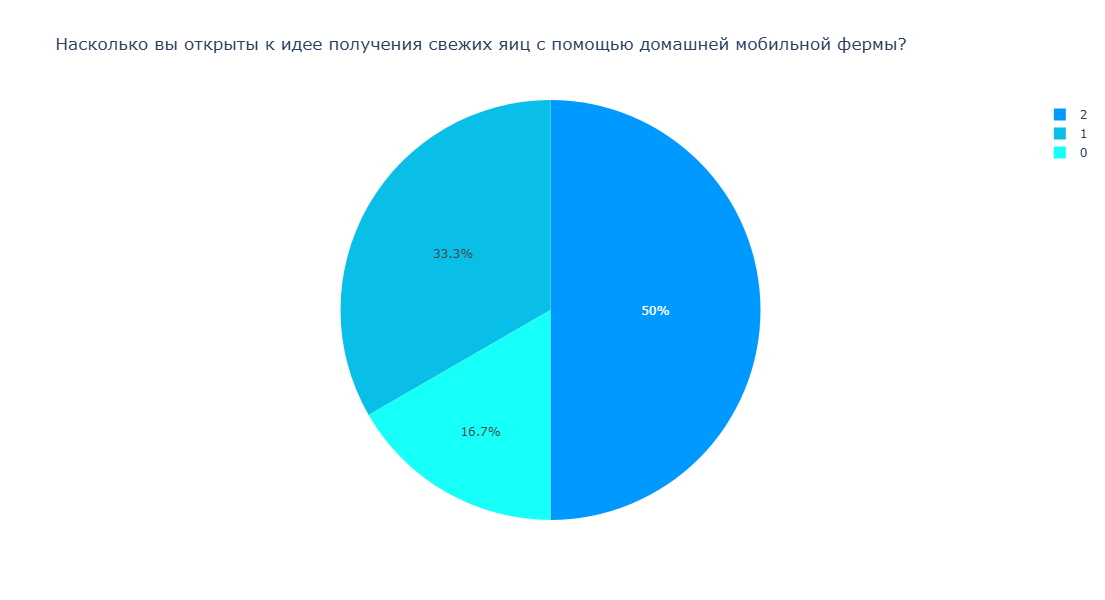

In [106]:
readiness_cnt = pd.DataFrame(filtered_df['Насколько вы открыты к идее получения свежих яиц с помощью домашней мобильной фермы? (2 — классная идея, -2 — идея не очень)'].value_counts().reset_index())
readiness_cnt.columns = ['Ответ', 'Количество людей']
fig = px.pie(readiness_cnt, values='Количество людей', names='Ответ', title='Насколько вы открыты к идее получения свежих яиц с помощью домашней мобильной фермы?', color_discrete_sequence=['#0099ff', '#09bfe8', '#17fff9'])
fig.update_layout(width=1000, height=600)

fig.show()

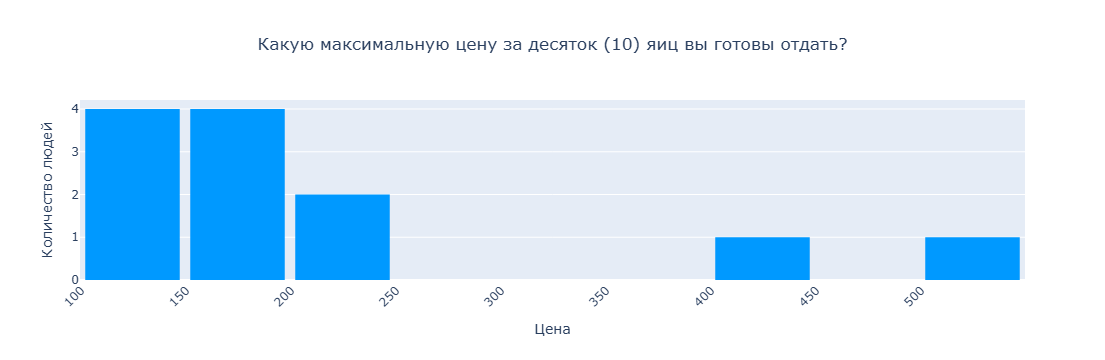

In [128]:
fig = px.histogram(filtered_df, x="Какую максимальную цену за десяток (10) яиц вы готовы отдать?", nbins=8, title="Какую максимальную цену за десяток (10) яиц вы готовы отдать?", color_discrete_sequence=['#0099ff'])
fig.update_layout(
    xaxis_title="Цена",
    yaxis_title="Количество людей",
    bargap=0.1,
    width = 800,
    title_x = 0.5
)
fig.update_xaxes(dtick=50, tickangle = -45)
fig.show()

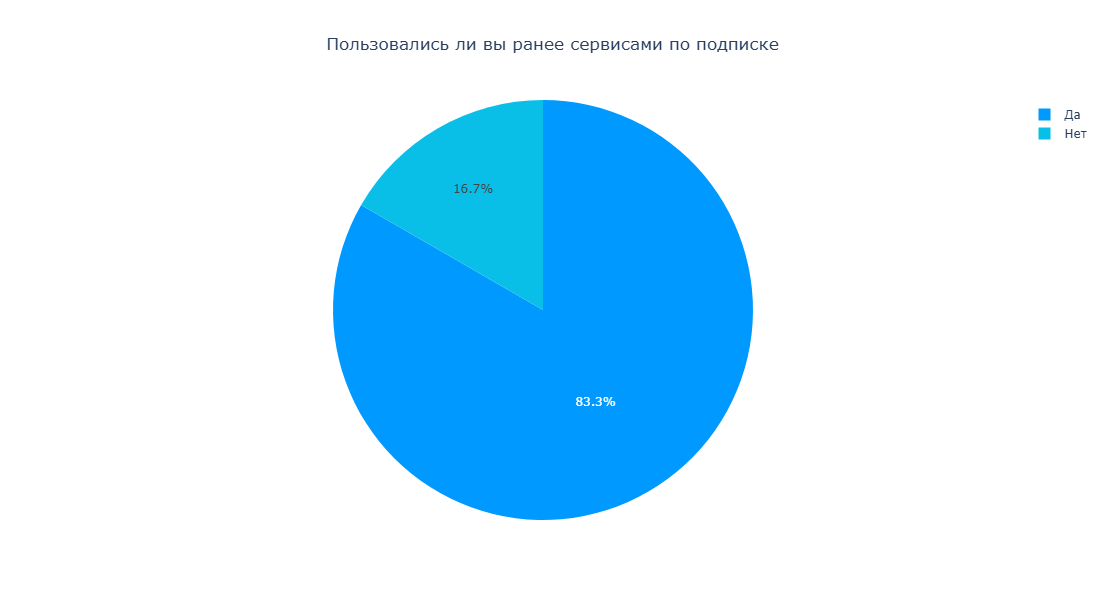

In [150]:
clm = filtered_df.columns[5]
cur_df = pd.DataFrame(filtered_df[clm].value_counts().reset_index())
cur_df.columns = ['Ответ', 'Количество людей']
fig = px.pie(cur_df, values='Количество людей', names='Ответ', title='Пользовались ли вы ранее сервисами по подписке', color_discrete_sequence=['#0099ff', '#09bfe8', '#17fff9'])
fig.update_layout(width=1000, height=600, title_x = 0.5)

fig.show()

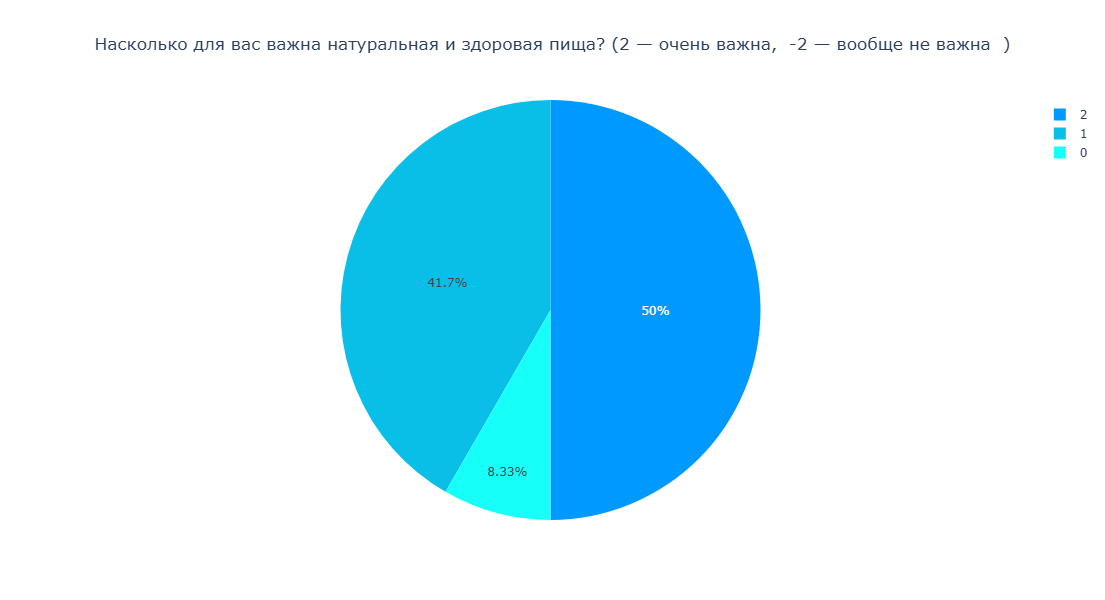

In [152]:
clm = filtered_df.columns[1]
cur_df = pd.DataFrame(filtered_df[clm].value_counts().reset_index())
cur_df.columns = ['Ответ', 'Количество людей']
fig = px.pie(cur_df, values='Количество людей', names='Ответ', title=clm, color_discrete_sequence=['#0099ff', '#09bfe8', '#17fff9'])
fig.update_layout(width=1000, height=600, title_x = 0.5)

fig.show()

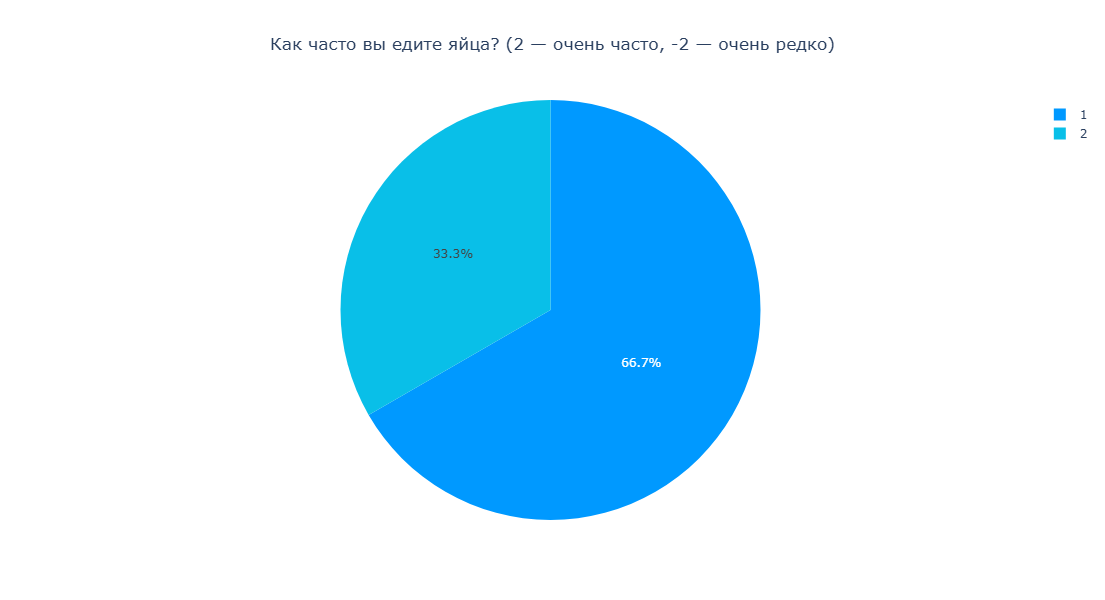

In [156]:
clm = filtered_df.columns[2]
cur_df = pd.DataFrame(filtered_df[clm].value_counts().reset_index())
cur_df.columns = ['Ответ', 'Количество людей']
fig = px.pie(cur_df, values='Количество людей', names='Ответ', title=clm, color_discrete_sequence=['#0099ff', '#09bfe8', '#17fff9'])
fig.update_layout(width=1000, height=600, title_x = 0.5)

fig.show()

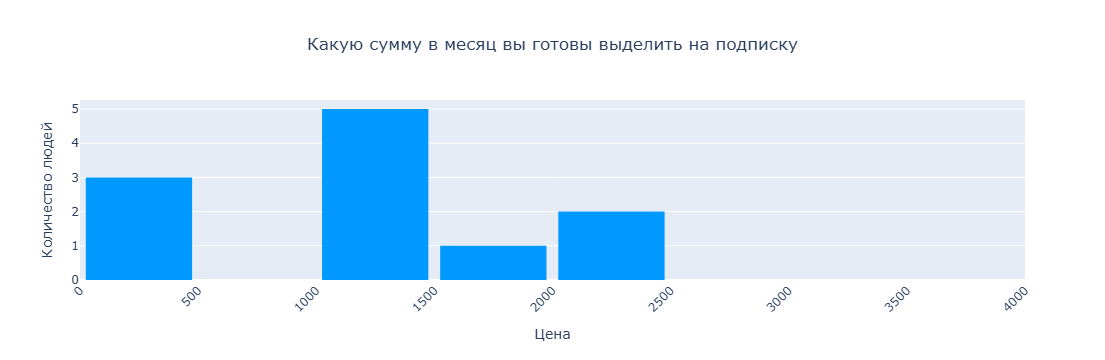

In [176]:
clm = filtered_df.columns[-2]
fig = px.histogram(filtered_df, x=clm, nbins=24, title='Какую сумму в месяц вы готовы выделить на подписку', color_discrete_sequence=['#0099ff'])
fig.update_layout(
    xaxis_title="Цена",
    yaxis_title="Количество людей",
    bargap=0.1,
    width = 800,
    title_x = 0.5
)
fig.update_xaxes(tickangle = -45, range = [0, 4000])
fig.show()